# Importing libraries

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

Ignore the sections that have *(Optional)* in them

# Loading the Data

I decided to not include 2025 data for now since it's incomplete. Not all licensure exams have been administered this year.

In [2]:
# Load the three datasets uploaded by the user
file_2023 = "PRC 2023.csv"
file_2024 = "PRC 2024.csv"

df_2023 = pd.read_csv(file_2023)
df_2024 = pd.read_csv(file_2024)

# Display basic info about each dataframe to check structure
df_2023_info = df_2023.info()
df_2024_info = df_2024.info()

df_2023_head = df_2023.head()
df_2024_head = df_2024.head()

(df_2023_info, df_2023_head,
 df_2024_info, df_2024_head)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   job_sector    46 non-null     object 
 1   year          46 non-null     int64  
 2   passers       46 non-null     int64  
 3   examinees     46 non-null     int64  
 4   passing_rate  46 non-null     float64
 5   source        46 non-null     object 
 6   Unnamed: 6    33 non-null     object 
dtypes: float64(1), int64(3), object(3)
memory usage: 2.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   job_sector    46 non-null     object 
 1   year          46 non-null     int64  
 2   passers       46 non-null     int64  
 3   examinees     46 non-null     int64  
 4   passing_rate  46 non-null     float64
 5   source        46 non-null     object 
dty

(None,
              job_sector  year  passers  examinees  passing_rate  \
 0           Accountancy  2023     2740       8734         31.37   
 1           Agriculture  2023     3423      10014         34.18   
 2          Architecture  2023     2924       4784         61.12   
 3  Chemical Engineering  2023      651        927         70.23   
 4             Chemistry  2023      594       1148         51.74   
 
                                               source  \
 0  https://www.philstar.com/exam-results/2023/10/...   
 1  https://www.thesummitexpress.com/2023/11/full-...   
 2  https://www.philstar.com/exam-results/2023/06/...   
 3  https://www.thesummitexpress.com/2023/10/full-...   
 4  https://www.philstar.com/other-sections/exam-r...   
 
                                   Unnamed: 6  
 0  and%20Zamboanga%20last%20September%202023  
 1        working%20days%20after%20the%20exam  
 2              June%209%20and%2011%2C%202023  
 3       the%20last%20day%20of%20examinations  

# Cleaning the Data

Keeping only necessary columns. No need for sources.

In [12]:
cols_to_keep = ["job_sector", "year", "passers", "examinees", "passing_rate"]
df_2023 = df_2023[cols_to_keep]
df_2024 = df_2024[cols_to_keep]

Combining datasets and dropping duplicates

In [13]:
df_all = pd.concat([df_2023, df_2024], ignore_index=True).drop_duplicates()

Pivot for sector-to-sector comparison (passing rates)

In [14]:
df_compare = df_all.pivot(index="job_sector", columns="year", values="passing_rate").reset_index()

Computing for absolute, relative change, and average passing rate

In [15]:
df_compare["abs_change"] = df_compare[2024] - df_compare[2023]
df_compare["rel_change_%"] = ((df_compare[2024] - df_compare[2023]) / df_compare[2023]) * 100
df_compare["avg_passing_rate"] = df_compare[[2023, 2024]].mean(axis=1)
df_compare_sorted = df_compare.sort_values("abs_change", ascending=True)

df_compare_sorted

year,job_sector,2023,2024,abs_change,rel_change_%,avg_passing_rate
24,Mechanical Engineering,50.34,32.83,-17.51,-34.783472,41.585
21,Interior Design,45.60,29.75,-15.85,-34.758772,37.675
23,Library Science,62.64,48.77,-13.87,-22.142401,55.705
9,Customs Brokers,57.07,44.06,-13.01,-22.796566,50.565
11,Dentistry,75.00,67.83,-7.17,-9.560000,71.415
26,Medicine,63.24,58.26,-4.98,-7.874763,60.750
32,Nutrition and Dietetics,73.42,69.73,-3.69,-5.025879,71.575
39,Psychometrician,73.27,69.78,-3.49,-4.763205,71.525
25,Medical Technology,72.06,69.47,-2.59,-3.594227,70.765
0,Accountancy,31.37,30.17,-1.20,-3.825311,30.770


# Top/Bottom 5 Sectors For Each Year

## Job Sector Passing Rates in 2023 (*Optional*)

Graph is too big to be shown, so I just decided to do top 5 job sectors with highest/lowest passing rates in each year. Could be ignored.

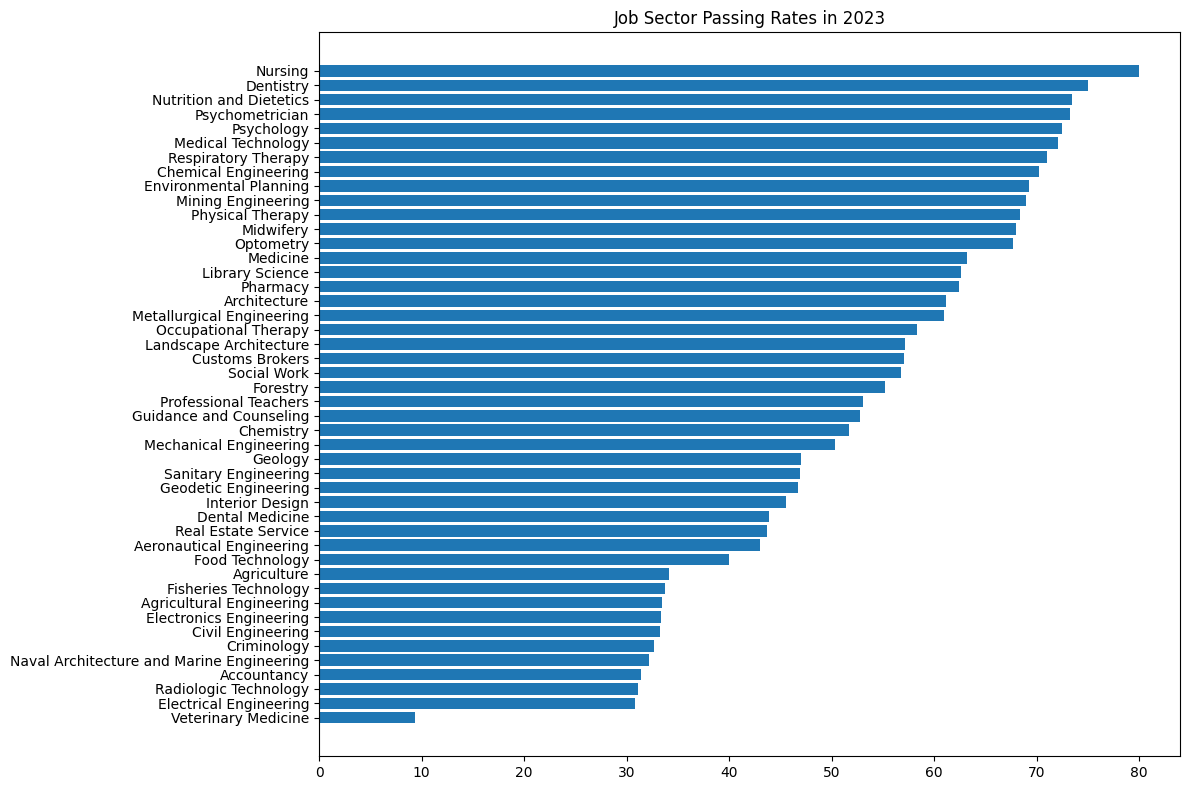

In [8]:
df_compare.sort_values(by=2023, inplace=True)

plt.figure(figsize=(12, 8))
plt.barh(
    y=df_compare['job_sector'],
    width=df_compare[2023]
)
plt.title("Job Sector Passing Rates in 2023")


plt.tight_layout()
plt.show()

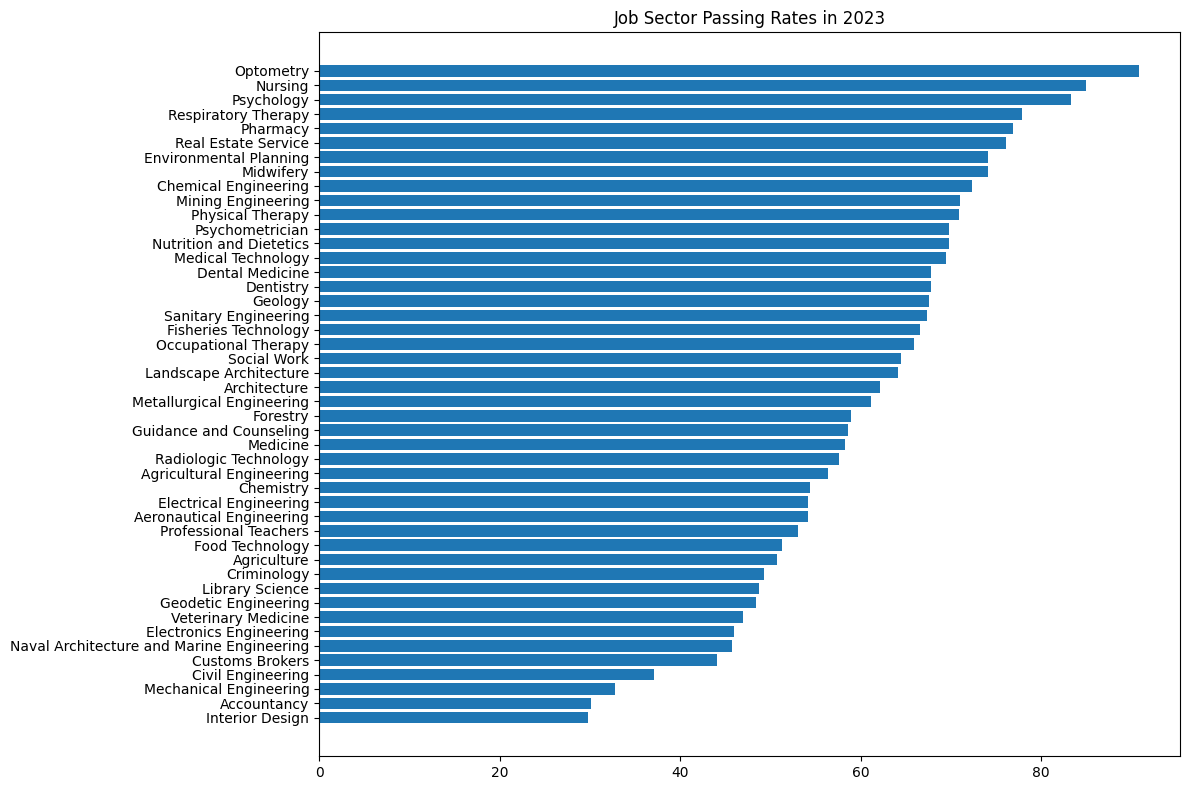

In [57]:
df_compare.sort_values(by=2024, inplace=True)

plt.figure(figsize=(12, 8))
plt.barh(
    y=df_compare['job_sector'],
    width=df_compare[2024]
)
plt.title("Job Sector Passing Rates in 2023")


plt.tight_layout()
plt.show()


# Boxplot

Function for boxplot

In [16]:
def plot_passing_rate_boxplots(df_all):
    """
    Expects columns: 'year' (int) and 'passing_rate' (float, in %).
    Draws a simple boxplot comparing 2023 vs 2024.
    """
    # Keep only years we have and sort order
    years = [2023, 2024]
    data = [df_all.loc[df_all["year"] == y, "passing_rate"].dropna() for y in years]

    plt.figure(figsize=(8, 5))
    bp = plt.boxplot(
        data,
        labels=[str(y) for y in years],
        showmeans=True,       # mean line
        meanline=True,
        patch_artist=True,    # nicer boxes
        vert=True
    )
    # Optional: make it easier to read
    plt.ylim(0, 100)
    plt.ylabel("Passing rate (%)")
    plt.title("Passing Rates by Year")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

C:\Users\Raymond\AppData\Local\Temp\ipykernel_21212\3484417084.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


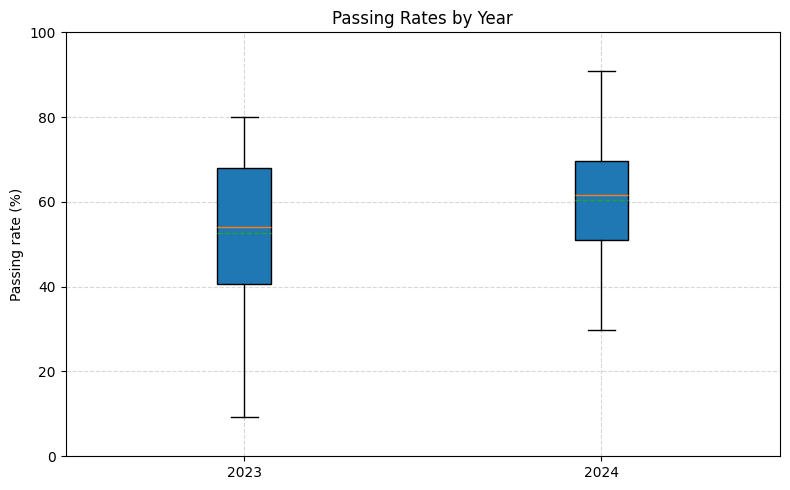

In [17]:
plot_passing_rate_boxplots(df_all)

The box plot above provides a generalization of the PRC passing rates in 2023 and 2024. In terms of the median, it should be noted that the 2024 median is around the 60% range, as compared to the 2023 median, which is positioned slightly above 50%. The longer IQR from 2023 suggests a wider distribution of passing rates. As for 2024, the smaller IQR suggests the passing rates were clustered closer to the median; there is less of an extremity in the difference between the high-performing and low-performing sectors. Outside the IQR, the 2023 box plot shows a minimum value around 10% and a maximum of 80%. In 2024, the distribution shifted upward, with a minimum value of approximately 30% and a maximum value around 90%. These characteristics reveal that passing rates showed an improvement and became more consistent across sectors in a year’s timespan.

# Bar Charts

## Top and Bottom 5 Passing Rates for Each Year

Extracting the top/bottom 5 passing rates for each year

In [21]:
# Top 5 sectors in 2023
top5_2023 = df_compare.nlargest(5, 2023)[["job_sector", 2023]].sort_values(by=2023, ascending=True)
bottom5_2023 = df_compare.nsmallest(5, 2023)[["job_sector", 2023]]

# Top 5 sectors in 2024
top5_2024 = df_compare.nlargest(5, 2024)[["job_sector", 2024]].sort_values(by=2024, ascending=True)
bottom5_2024 = df_compare.nsmallest(5, 2024)[["job_sector", 2024]]


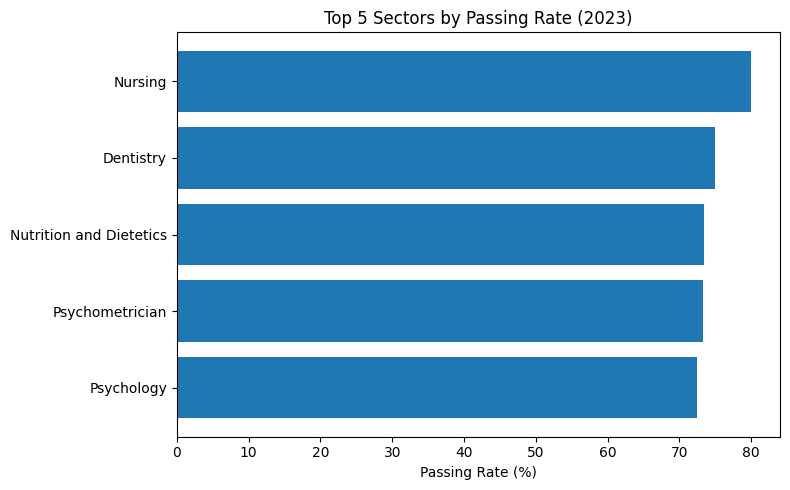

In [18]:
plt.figure(figsize=(8, 5))
plt.barh(top5_2023["job_sector"], top5_2023[2023],)
plt.title("Top 5 Sectors by Passing Rate (2023)")
plt.xlabel("Passing Rate (%)")
plt.tight_layout()
plt.show()


The bar chart above shows the sectors with the top five passing rates in 2023. Nursing tops the list with a passing rate of around 80%. This is then followed by the following fields: dentistry, nutrition and dietetics, psychometrician, and psychology. As could be noticed, all of the passing rates lie within the 70 to 80% range; their values cluster tightly together and do not vary from one another. In relation to the previous figure, these sectors would be found in the upper tail of the 2023 box plot.

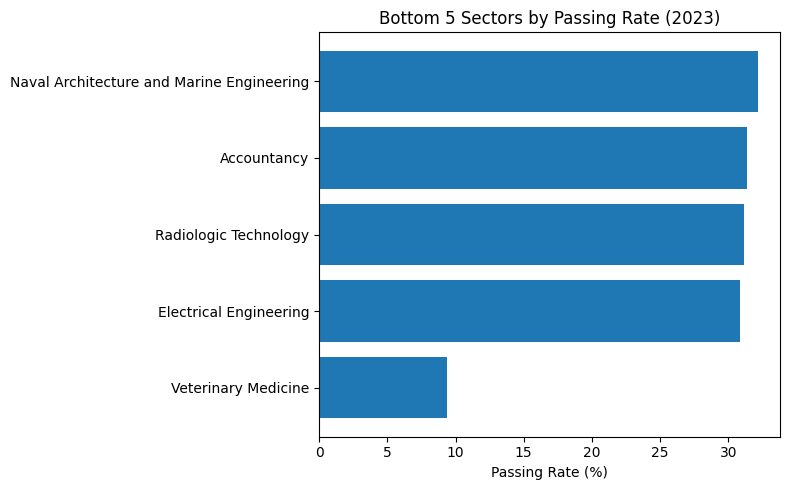

In [19]:
plt.figure(figsize=(8, 5))
plt.barh(bottom5_2023["job_sector"], bottom5_2023[2023])
plt.title("Bottom 5 Sectors by Passing Rate (2023)")
plt.xlabel("Passing Rate (%)")
plt.tight_layout()
plt.show()

In 2023, the bottom five sectors in terms of passing rates would be the following: Naval Architecture and Marine Engineering, Accountancy, Radiologic Technology, Electrical Engineering, and Veterinary Medicine. In comparison with its top sector counterparts, there is less uniformity between the passing rates of these sectors. This trend is shown by the lowest-performing field, Veterinary Medicine, which has around a 20% difference from the other sectors in the bar chart.

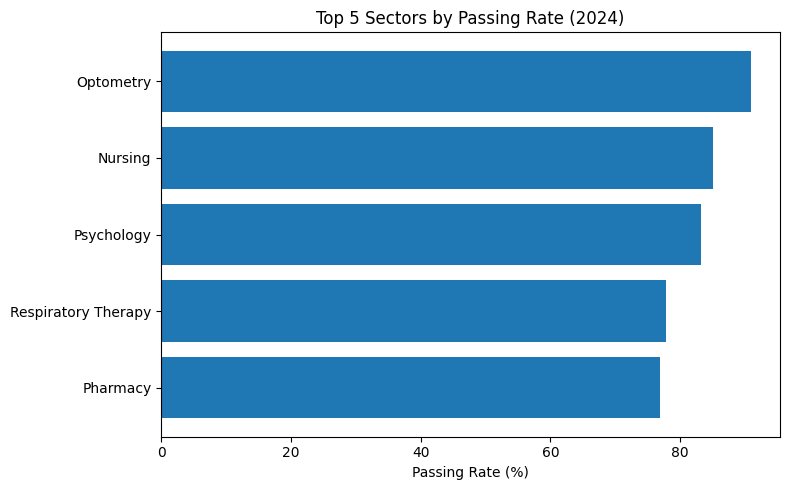

In [22]:
plt.figure(figsize=(8, 5))
plt.barh(top5_2024["job_sector"], top5_2024[2024])
plt.title("Top 5 Sectors by Passing Rate (2024)")
plt.xlabel("Passing Rate (%)")
plt.tight_layout()
plt.show()


The top five sectors in terms of passing rates in 2024 are optometry, nursing, psychology, respiratory therapy, and pharmacy. Compared to 2023, there were changes in most sectors—most likely indicating a change in demand in the labor market. The only exception would be nursing, which consistently takes a top spot in 2024. Similar to the 2023 top sectors, the values are also uniform, lying in the 70 to 80% range.

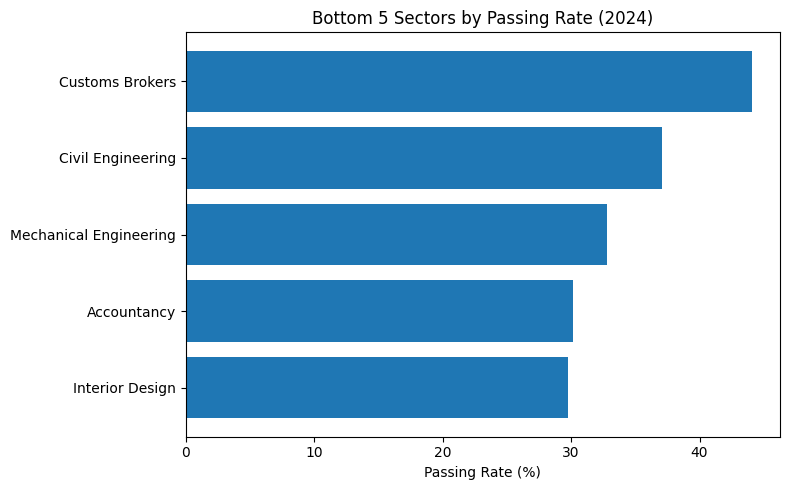

In [55]:
plt.figure(figsize=(8, 5))
plt.barh(bottom5_2024["job_sector"], bottom5_2024[2024])
plt.title("Bottom 5 Sectors by Passing Rate (2024)")
plt.xlabel("Passing Rate (%)")
plt.tight_layout()
plt.show()

Unlike 2023, where veterinary medicine dragged the floor near 10%, the lowest in 2024 is higher (~29–30%), showing some improvement in the weakest sectors. Accountancy shows up again, proving it's a field that struggles year-to-year. Considering that engineering disciplines (mechanical and civil) appear in the chart, it suggests persistent difficulty or high exam failure rates in technical fields. The gap between the top and bottom sectors remains large—with optometry at around 90% versus interior design/accountancy at approximately 29%, a 60-point difference.


## Comparison of top 5 sectors in 2024 with its 2023 counterparts (*Optional*)
Optional as of now: Will assess later if this should be presented depending on the length of the overall presentation. Also, this is already covered in the absolute and relative change.

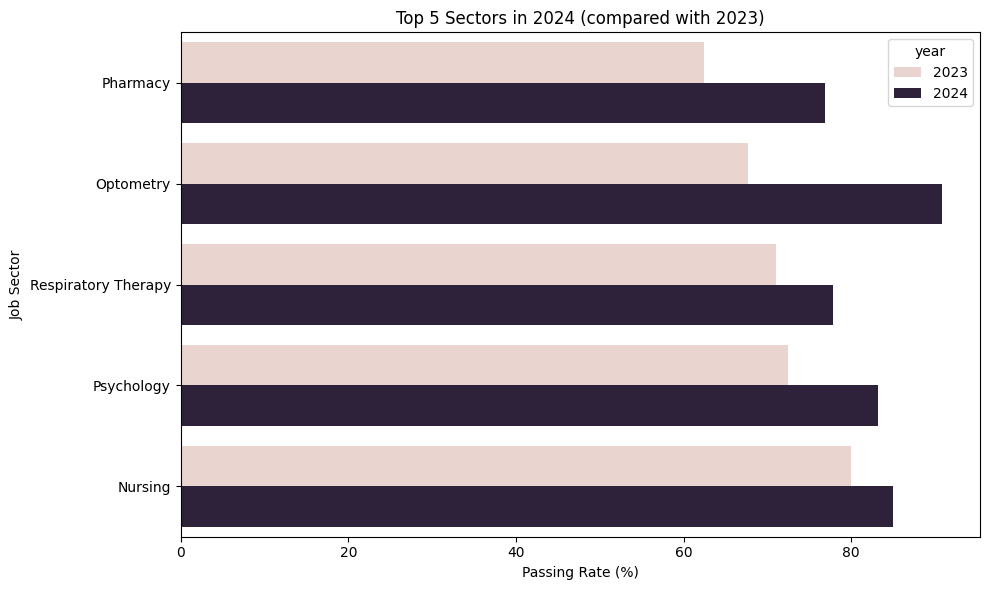

In [ ]:
df_long = df_compare.melt(
    id_vars="job_sector",
    value_vars=[2023, 2024],
    var_name="year",
    value_name="passing_rate"
)

# Plot top 5 of 2024 across both years
import seaborn as sns

top_sectors = top5_2024["job_sector"].tolist()

plt.figure(figsize=(10,6))
sns.barplot(
    data=df_long[df_long["job_sector"].isin(top_sectors)],
    x="passing_rate",
    y="job_sector",
    hue="year"
)
plt.title("Top 5 Sectors in 2024 (compared with 2023)")
plt.xlabel("Passing Rate (%)")
plt.ylabel("Job Sector")
plt.tight_layout()
plt.show()


# Side by Side Bar Chart

C:\Users\Raymond\AppData\Local\Temp\ipykernel_24856\1022116448.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


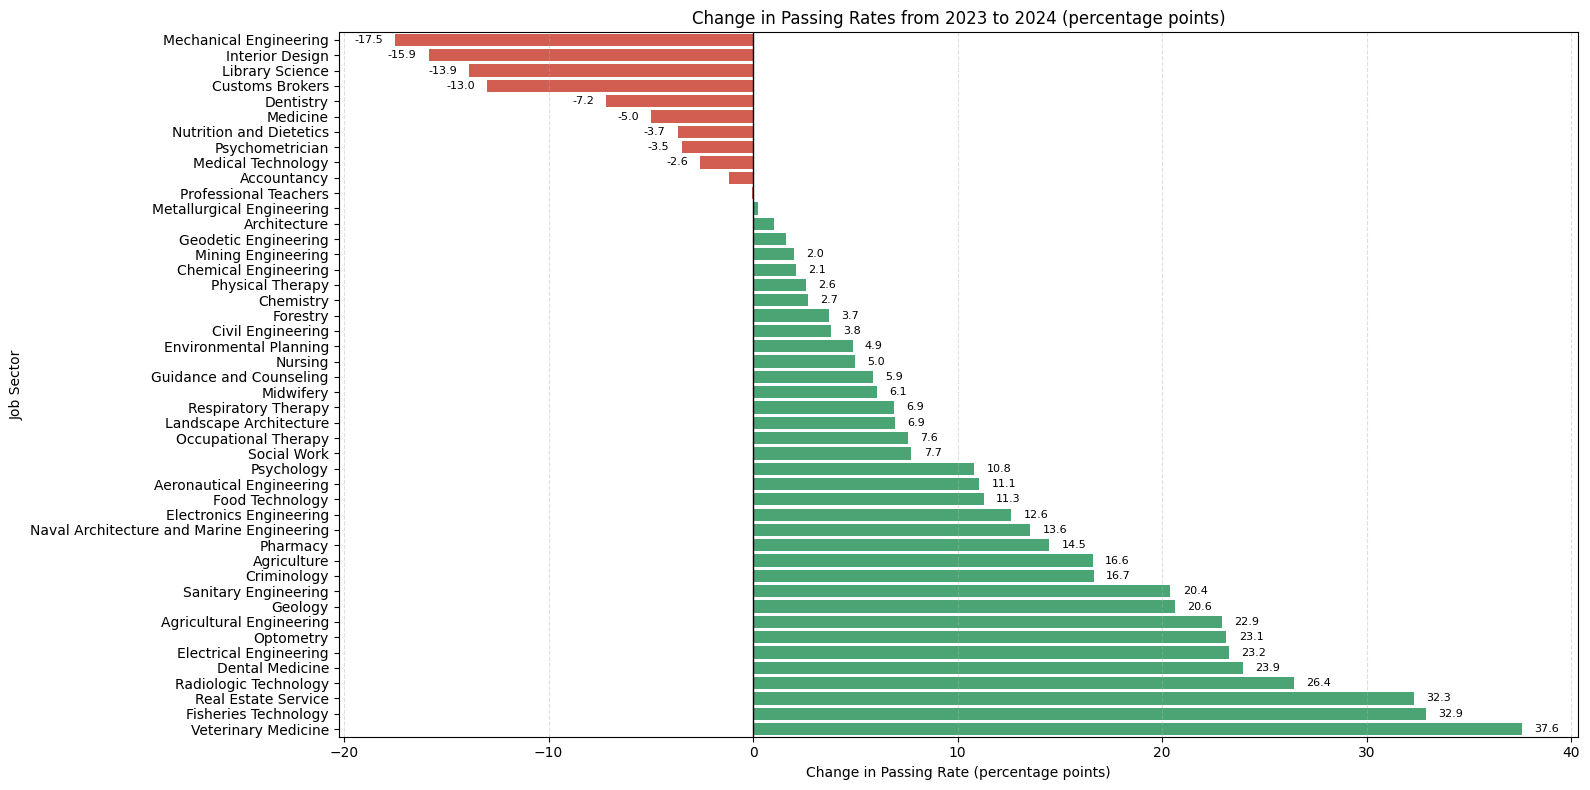

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by absolute change
df_sorted = df_compare.sort_values("abs_change")

# color by sign
def sign_colors(series, pos="#3CB371", neg="#E74C3C"):
    return [pos if v >= 0 else neg for v in series]

plt.figure(figsize=(16, 8))
sns.barplot(
    data=df_sorted,
    y="job_sector", x="abs_change",
    palette=sign_colors(df_sorted["abs_change"])
)
plt.axvline(0, color="black", lw=1)
plt.title("Change in Passing Rates from 2023 to 2024 (percentage points)")
plt.xlabel("Change in Passing Rate (percentage points)")
plt.ylabel("Job Sector")
plt.grid(True, axis="x", ls="--", alpha=0.4)

# annotate bars
for p in plt.gca().patches:
    w = p.get_width()
    if abs(w) >= 2:
        plt.text(w + (0.6 if w>=0 else -0.6),
                 p.get_y() + p.get_height()/2,
                 f"{w:.1f}",
                 va="center",
                 ha="left" if w>=0 else "right",
                 fontsize=8)

plt.tight_layout()
plt.show()


C:\Users\Raymond\AppData\Local\Temp\ipykernel_24856\2204935025.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


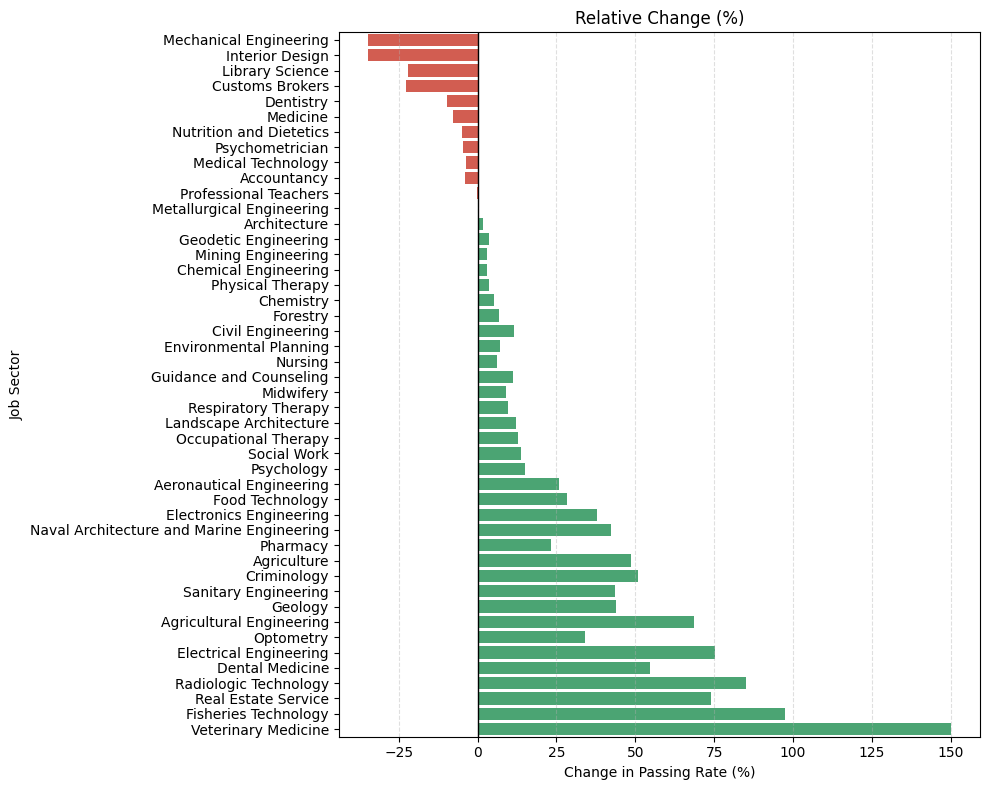

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by absolute change so y-axis order matches the first chart
df_sorted = df_compare.sort_values("abs_change")

# color by sign
def sign_colors(series, pos="#3CB371", neg="#E74C3C"):
    return [pos if v >= 0 else neg for v in series]

plt.figure(figsize=(10, 8))

# Optional: clip outliers
rel = df_sorted["rel_change_%"].clip(lower=-100, upper=150)

sns.barplot(
    y=df_sorted["job_sector"], x=rel,
    palette=sign_colors(rel)
)
plt.axvline(0, color="black", lw=1)
plt.title("Relative Change (%)")
plt.xlabel("Change in Passing Rate (%)")
plt.ylabel("Job Sector")
plt.grid(True, axis="x", ls="--", alpha=0.4)

plt.tight_layout()
plt.show()


# Scatter plot: examinees vs. passing rate

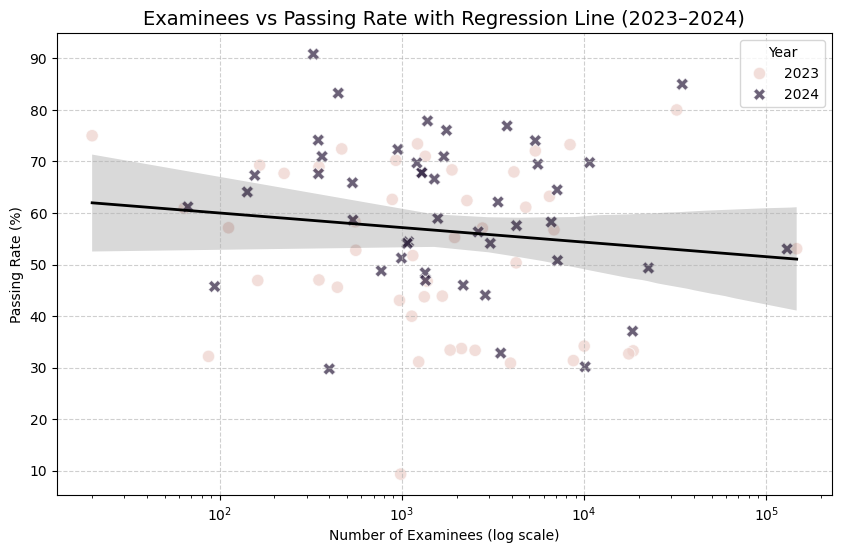

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

# Scatter points
sns.scatterplot(
    data=df_all,
    x="examinees",
    y="passing_rate",
    hue="year",
    style="year",
    s=80,
    alpha=0.7
)

# Regression line (logarithmic x-axis handled by taking log transform)
sns.regplot(
    data=df_all,
    x="examinees",
    y="passing_rate",
    scatter=False,        # don’t duplicate scatter points
    logx=True,            # log-transform x for regression fit
    line_kws={"color":"black", "lw":2}  # style of regression line
)

plt.title("Examinees vs Passing Rate with Regression Line (2023–2024)", fontsize=14)
plt.xlabel("Number of Examinees (log scale)")
plt.ylabel("Passing Rate (%)")
plt.xscale("log")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Year")
plt.show()

In [ ]:
corr = df_all['examinees'].corr(df_all['passing_rate'])

# Pearson correlation (linear relationship)
pearson_corr = df_all["examinees"].corr(df_all["passing_rate"], method="pearson")

# Spearman correlation (rank-based, monotonic relationship)
spearman_corr = df_all["examinees"].corr(df_all["passing_rate"], method="spearman")

print(f"correlation value: {corr:.4f}")
print(f"Pearson correlation: {pearson_corr:.4f}")
print(f"Spearman correlation: {spearman_corr:.4f}")

correlation value: -0.0310
Pearson correlation: -0.0310
Spearman correlation: -0.1253


There is almost no correlation between the number of examinees and the passing rate (Pearson r = –0.03; Spearman ρ = –0.12). This suggests that exam size does not systematically affect success rates — passing rates are likely driven by exam difficulty and sector-specific factors, not the volume of takers.

In [30]:
df_all['examinees'].corr(df_all['passing_rate'])

np.float64(-0.03100976035888645)

Correlation between Examinees and Passers: 0.9889743604081683
Correlation between Examinees and Passing Rate: -0.03100976035888645
Correlation between Passers and Passing Rate: 0.04583053107744581


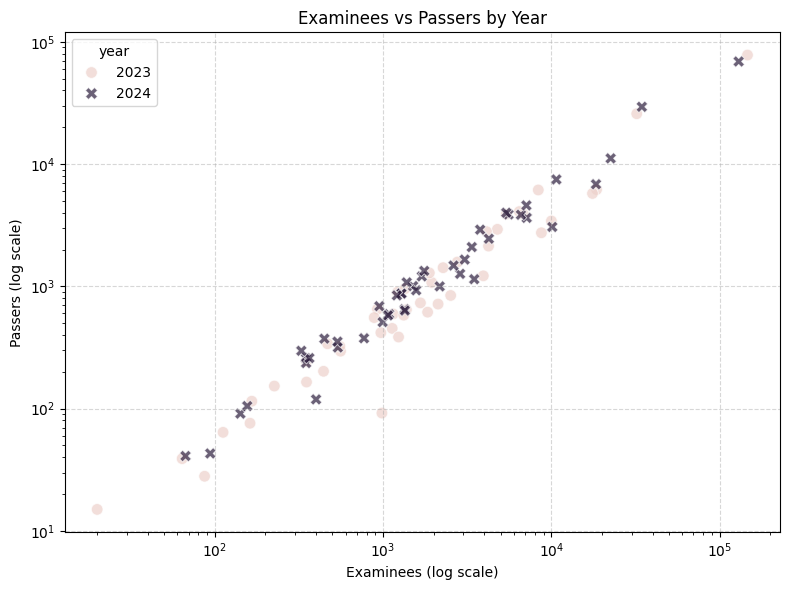

In [29]:
# Correlation values
corr_examinees_passers = df_all["examinees"].corr(df_all["passers"])
corr_examinees_passing_rate = df_all["examinees"].corr(df_all["passing_rate"])
corr_passers_passing_rate = df_all["passers"].corr(df_all["passing_rate"])

print("Correlation between Examinees and Passers:", corr_examinees_passers)
print("Correlation between Examinees and Passing Rate:", corr_examinees_passing_rate)
print("Correlation between Passers and Passing Rate:", corr_passers_passing_rate)

# 2. Scatter plot: Examinees vs Passers
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_all,
    x="examinees",
    y="passers",
    hue="year",
    style="year",
    s=70,
    alpha=0.7
)
plt.xscale("log")   # because examinees vary a lot
plt.yscale("log")   # same for passers
plt.xlabel("Examinees (log scale)")
plt.ylabel("Passers (log scale)")
plt.title("Examinees vs Passers by Year")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


Pearson r (overall): 0.989
Spearman ρ (overall): 0.973

Pearson r by year:
year
2023    0.990890
2024    0.986885
Name: (passers, examinees), dtype: float64


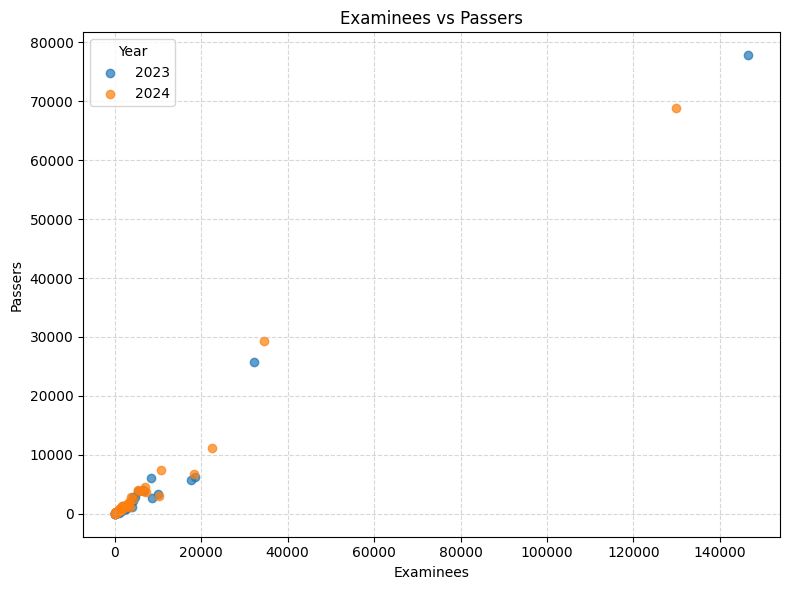

In [25]:
# 1) Basic correlations (overall + by year)
pearson_overall = df_all["examinees"].corr(df_all["passers"], method="pearson")
spearman_overall = df_all["examinees"].corr(df_all["passers"], method="spearman")
print(f"Pearson r (overall): {pearson_overall:.3f}")
print(f"Spearman ρ (overall): {spearman_overall:.3f}")

by_year = (
    df_all.groupby("year")[["examinees", "passers"]]
          .corr(method="pearson")
          .unstack()
)
print("\nPearson r by year:")
print(by_year.loc[:, ("passers", "examinees")])

# 2) Scatter (linear scales)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
for y, g in df_all.groupby("year"):
    plt.scatter(g["examinees"], g["passers"], label=y, alpha=0.7)

plt.xlabel("Examinees")
plt.ylabel("Passers")
plt.title("Examinees vs Passers")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Year")
plt.tight_layout()
plt.show()

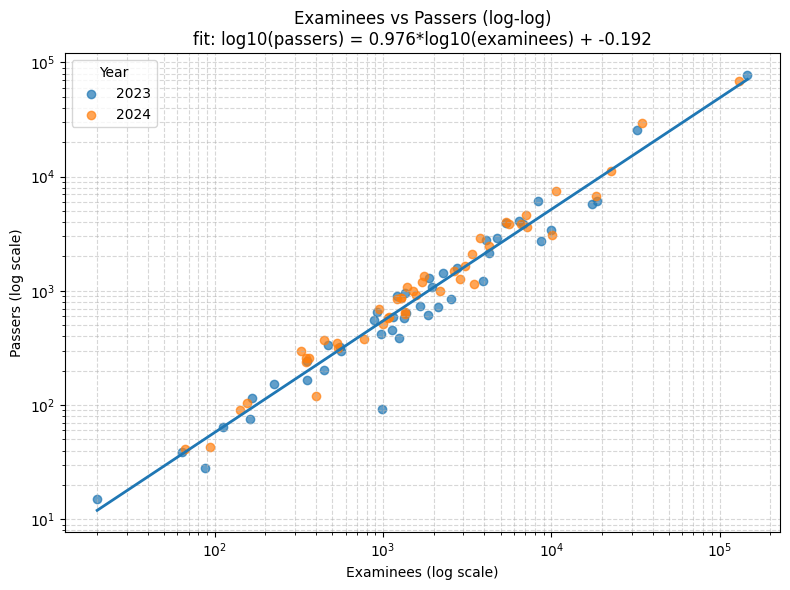

In [26]:
# 3) Scatter with log scales + simple regression line (on log-log)
import numpy as np

d = df_all[(df_all["examinees"] > 0) & (df_all["passers"] > 0)].copy()
x = np.log10(d["examinees"].values)
y = np.log10(d["passers"].values)

# fit line in log-log
m, b = np.polyfit(x, y, 1)
y_fit = m * x + b

plt.figure(figsize=(8,6))
for yr, g in d.groupby("year"):
    plt.scatter(g["examinees"], g["passers"], label=yr, alpha=0.7)

# plot fitted line across full range
x_line = np.linspace(x.min(), x.max(), 200)
y_line = m * x_line + b
plt.plot(10**x_line, 10**y_line, linewidth=2)  # back-transform to original scale

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Examinees (log scale)")
plt.ylabel("Passers (log scale)")
plt.title(f"Examinees vs Passers (log-log)\nfit: log10(passers) = {m:.3f}*log10(examinees) + {b:.3f}")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(title="Year")
plt.tight_layout()
plt.show()


# Heatmap *(Optional)*

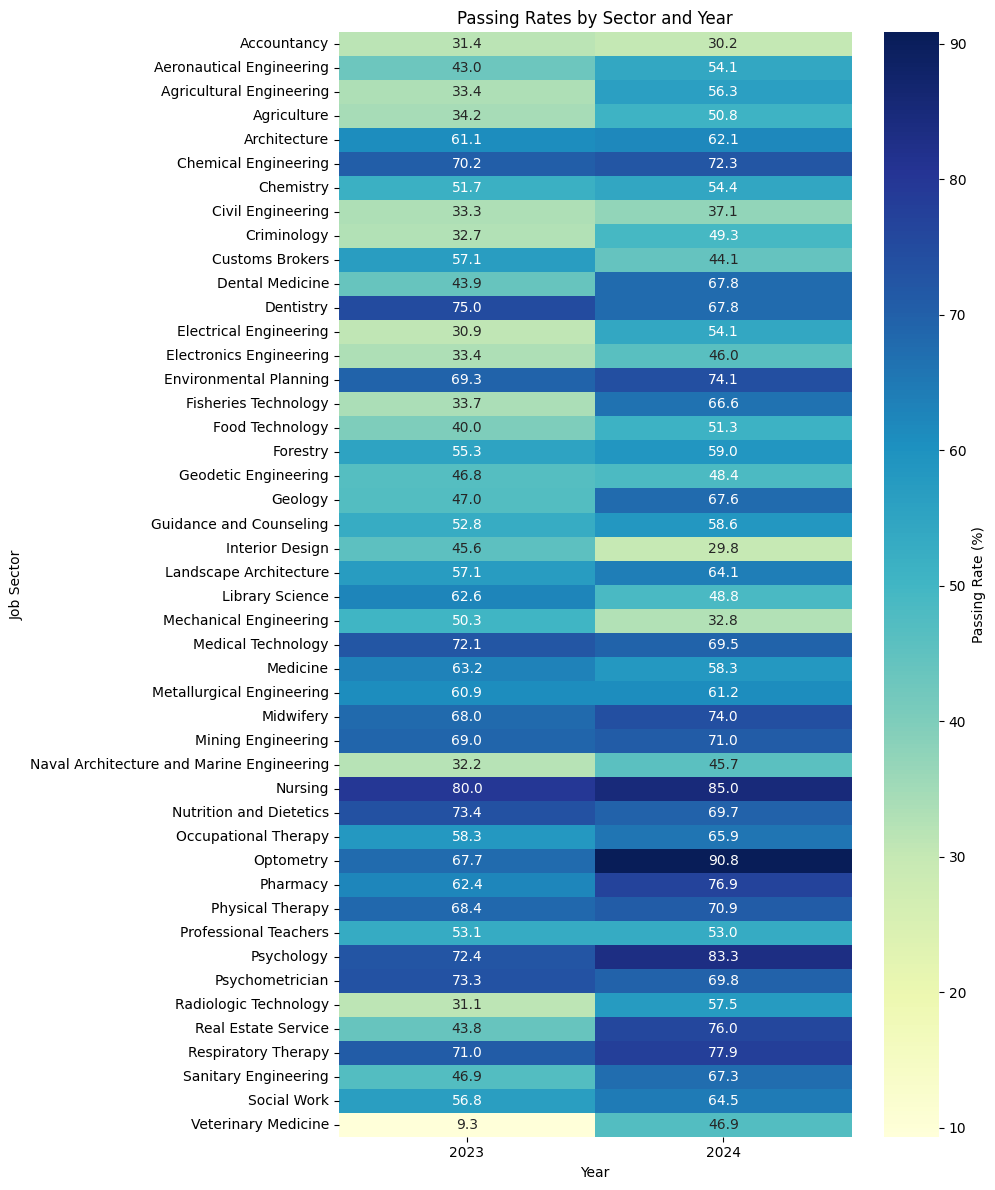

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pivot to get job_sector as rows and years as columns
heatmap_data = df_all.pivot_table(
    index="job_sector",
    columns="year",
    values="passing_rate"
)

plt.figure(figsize=(10, 12))
sns.heatmap(
    heatmap_data,
    annot=True,        # show passing rate values
    fmt=".1f",         # format with 1 decimal place
    cmap="YlGnBu",     # color scheme
    cbar_kws={'label': 'Passing Rate (%)'}
)

plt.title("Passing Rates by Sector and Year")
plt.xlabel("Year")
plt.ylabel("Job Sector")
plt.tight_layout()
plt.show()


# Other Code *(All Optinal)*

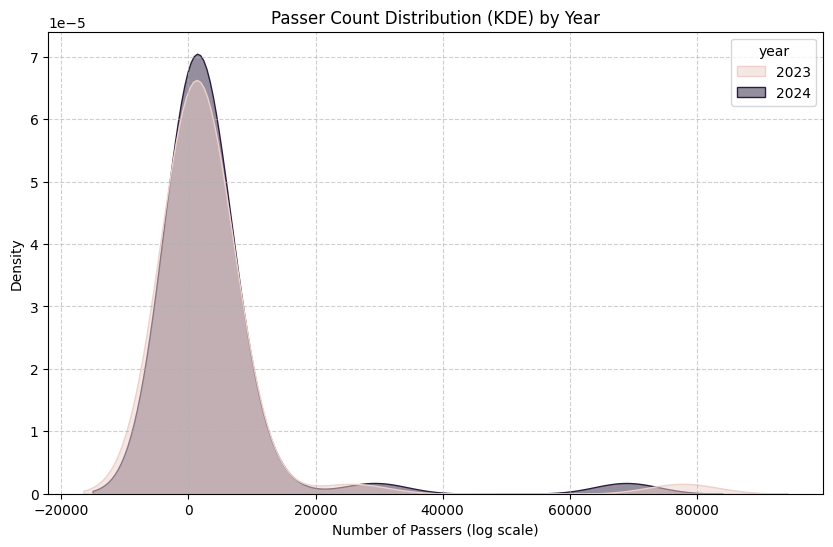

In [15]:
plt.figure(figsize=(10,6))
sns.kdeplot(
    data=df_all,
    x="passers",
    hue="year",
    common_norm=False,
    fill=True,
    alpha=0.5
)

# plt.xscale("log")
plt.xlabel("Number of Passers (log scale)")
plt.ylabel("Density")
plt.title("Passer Count Distribution (KDE) by Year")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


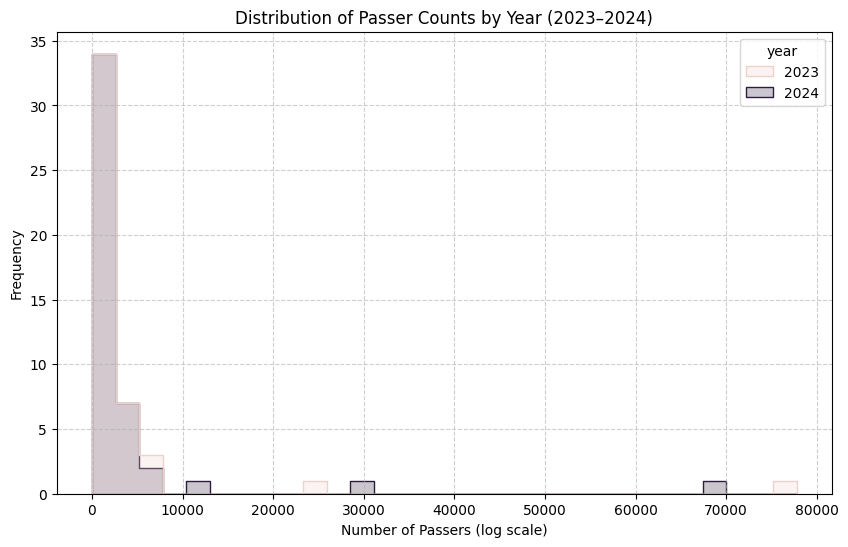

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(
    data=df_all,
    x="passers",
    bins=30,
    hue="year",
    element="step",
    kde=False
)

plt.xlabel("Number of Passers (log scale)")
plt.ylabel("Frequency")
plt.title("Distribution of Passer Counts by Year (2023–2024)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


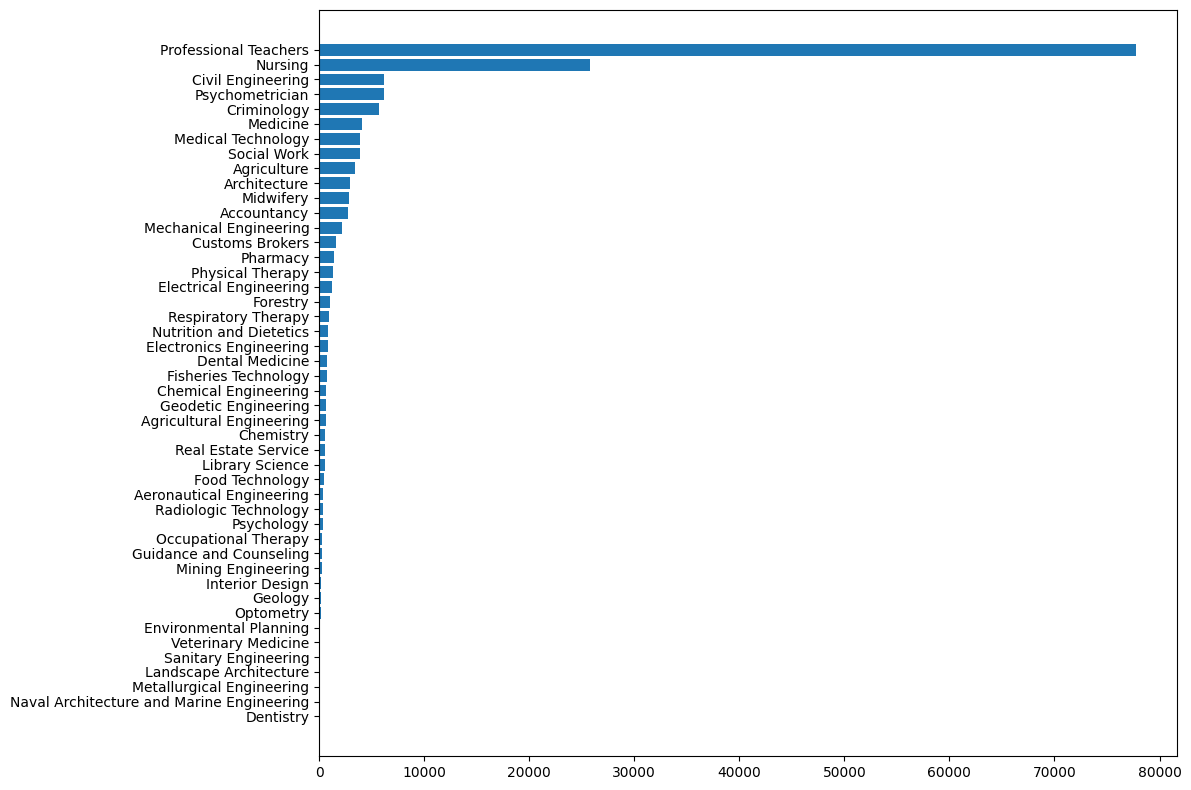

In [61]:
df_2023.sort_values(by='passers', inplace=True)
plt.figure(figsize=(12, 8))
plt.barh(width=df_2023['passers'],
         y=df_2023['job_sector'])
#plt.xscale('log')

plt.tight_layout()